# Notebook 12: does a reward aimed at the best subset make the controller matter?

Notebook 11 (H10a) found that warm-starting UCB1 did not help, and its diagnostics showed why:
- The bandit learned its reward exactly: its choice frequencies ranked the four moves in the same order as their mean rewards, on all ten datasets.
- The reward pointed at the wrong move. RL-DOHO's reward is 0.8 × (best-subset gain per evaluation) + 0.2 × (share of moved agents that beat the old median). The population term made **DO** the highest-rewarded move, even though DO improved the best subset in at most 11% of uses, against up to 28% for PERTURB and 22% for HO.
- The reward gaps were small next to UCB1's exploration bonus (c = 1), so the choices stayed close to uniform.

This notebook tests the two fixes that diagnosis suggests:

| Change | What it does |
|---|---|
| **Best-gain reward** | reward = min(1, g / g_max) only: credit only for improving the best subset, per evaluation spent (no population term) |
| **Smaller exploration constant** | c = 0.2 instead of 1, so the bandit acts more on what it has learned |

**Setup:** identical to Notebook 11. The Notebook 8 KNN protocol on the ten datasets (five gene-expression, five medical tabular), the original four moves, **3× budget** (3,060 evaluations, population 20) and ten seeds.

**Variants:**

| Variant | Controller | Reward | c | Role |
|---|---|---|---|---|
| Random, 4 moves | random | – | – | baseline (= Notebook 11) |
| UCB1, 4 moves | UCB1 | gain + population | 1 | current RL-DOHO (= Notebook 11) |
| UCB1, best-gain reward | UCB1 | best-gain only | 1 | **H11a** |
| UCB1, best-gain reward, c=0.2 | UCB1 | best-gain only | 0.2 | **H11b** |

The first two variants use exactly the Notebook 8/11 code and seeds. If those notebooks' caches are in your Drive, they cost almost nothing.

**Runtime:** about 1–1.5 hours for all ten datasets, or about 40 minutes each in two parallel sessions (`DATASETS = TABS` in one and `DATASETS = GENE` in the other). Each dataset saves to its own file, and every run is saved as soon as it finishes, so rerunning a cell resumes where it stopped. Run sections 7 onwards once, in any session, after all datasets are done.

### Hypotheses (fixed before any run of this notebook; every outcome is reported)

These were written after Notebook 11's diagnostics, which motivated them. The reward and c = 0.2 are fixed now and are not tuned.

Each is a pooled two-sided sign test on fitness over the 100 paired runs (10 datasets × 10 seeds), Holm-corrected over the two:
- **H11a:** UCB1 with the best-gain reward vs Random, 4 moves.
- **H11b:** UCB1 with the best-gain reward and c = 0.2 vs Random, 4 moves.

**Success rule, fixed in advance:** the reward change "makes the controller matter" only if H11a or H11b favours the learner at Holm p < 0.05 **and** that variant is not significantly worse than UCB1, 4 moves (the current RL-DOHO).

**Reported without a hypothesis:**
- Each new variant against the current RL-DOHO.
- Gene and tabular data separately, and test scores.
- Two diagnostics. The first checks whether the new reward ranks the moves by how often they improve the best subset. The second checks whether the bandit's choices follow that ranking and are less uniform than before.

A difference below 1e-12 counts as a tie.

In [1]:
# ================= 1. SETUP =================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os, time, pickle, warnings, urllib.request, gzip, math, hashlib, zipfile
import numpy as np, pandas as pd, scipy.io as sio, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, balanced_accuracy_score, precision_score, recall_score, accuracy_score
from scipy.stats import kruskal, spearmanr
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [2]:
# ================= 2. CONFIG =================
ROOT      = '/content/drive/MyDrive' if IN_COLAB else '.'
OUT_DIR   = f"{ROOT}/rl_doho_results_v6_reward"                 # results of this notebook
V5_DIR    = f"{ROOT}/rl_doho_results_v5_rl"                     # Notebook 11 (caches reused)
KNN_DIR   = f"{ROOT}/rl_doho_results_v3_knn"                    # Notebook 8 (caches, data, 3x-budget runs)
V2_DIR    = f"{ROOT}/rl_doho_results_v2_genes"                  # Notebook 7 (gene caches, 3x-budget runs)
PREV_DIRS = [f"{ROOT}/rl_doho_results_hd", f"{ROOT}/rl_doho_results_ra", f"{ROOT}/rl_doho_results_baselines_hd", V2_DIR, KNN_DIR, V5_DIR]
DATA_DIR  = f"{OUT_DIR}/data"
GENE      = ["colon", "ALLAML", "lung", "GLIOMA", "GSE93272"]
TAB       = {"WDBC": "breast_cancer_wisconsin_diagnostic", "Hepatitis": "hepatitis", "Dermatology": "dermatology",
             "SPECTF": "spectf", "Backache": "backache"}
TABS      = list(TAB)
DATASETS  = TABS + GENE              # to run in parallel: e.g. TABS in one Colab session and GENE in another
SEEDS     = list(range(10))
POP_SIZE  = 20
BUDGET    = POP_SIZE * 51            # 1,020: length of each warm-up run
LONG_BUDGET = 3 * BUDGET             # 3,060: every evaluated run
N_WARMUP  = 2                        # warm-up runs before a warm-started run (same training split, seeds 1000+s, 2000+s)
KNN_K, CV_FOLDS, TEST_SIZE = 5, 5, 0.3
ALPHA, BETA = 0.99, 0.01
N_TOP_RA  = 5000
SCORING   = {d: "accuracy" for d in GENE[:4]} | {"GSE93272": "balanced_accuracy"} | {d: "balanced_accuracy" for d in TABS}
VERBOSE   = False

# name -> (moves, controller, warm start, reward, UCB exploration constant c)
VARIANTS = {
    "Random, 4 moves":               ("ARMS4", "random", False, "gain", 1.0),
    "UCB1, 4 moves":                 ("ARMS4", "ucb",    False, "gain", 1.0),
    "UCB1, best-gain reward":        ("ARMS4", "ucb",    False, "best", 1.0),
    "UCB1, best-gain reward, c=0.2": ("ARMS4", "ucb",    False, "best", 0.2),
}
NAMES = list(VARIANTS)

FAST = False                         # True: 2 small datasets x 1 seed with small budgets, only to check the notebook runs
if FAST: DATASETS, SEEDS, BUDGET, LONG_BUDGET = ["Hepatitis", "colon"], [0], 200, 400

os.makedirs(DATA_DIR, exist_ok=True)
def init_for(D): return "sparse" if D > 100 else "dense"
def save_pkl(obj, path):
    tmp = path + ".tmp"
    with open(tmp, "wb") as f: pickle.dump(obj, f)
    os.replace(tmp, path)
def load_pkl(path):
    for p in (path, path + ".tmp"):
        if os.path.exists(p):
            try:
                with open(p, "rb") as f: return pickle.load(f)
            except Exception as e: print(f"WARNING: could not read {p} ({e})")
    return {}
print("Output folder:", OUT_DIR, "| datasets:", DATASETS, "| budget per run:", LONG_BUDGET)

Output folder: /content/drive/MyDrive/rl_doho_results_v6_reward | datasets: ['WDBC', 'Hepatitis', 'Dermatology', 'SPECTF', 'Backache', 'colon', 'ALLAML', 'lung', 'GLIOMA', 'GSE93272'] | budget per run: 3060


## 3. Data (the same files as Notebook 8; reused from your Drive when present)

In [3]:
DATA = {}
def first_existing(paths, default): return next((p for p in paths if os.path.exists(p)), default)
URL = "https://raw.githubusercontent.com/jundongl/scikit-feature/master/skfeature/data/{}.mat"
for name in [d for d in DATASETS if d in GENE and d != "GSE93272"]:
    path = first_existing([f"{d}/data/{name}.mat" for d in PREV_DIRS], f"{DATA_DIR}/{name}.mat")
    if not os.path.exists(path): urllib.request.urlretrieve(URL.format(name), path)
    d = sio.loadmat(path); DATA[name] = (d["X"].astype(float), d["Y"].ravel())
if "GSE93272" in DATASETS:
    gpath = first_existing([f"{d}/data/GSE93272_series_matrix.txt.gz" for d in PREV_DIRS], f"{DATA_DIR}/GSE93272_series_matrix.txt.gz")
    if not os.path.exists(gpath):
        urllib.request.urlretrieve("https://ftp.ncbi.nlm.nih.gov/geo/series/GSE93nnn/GSE93272/matrix/GSE93272_series_matrix.txt.gz", gpath)
    chars = []
    with gzip.open(gpath, "rt") as f:
        for line in f:
            if line.startswith("!Sample_geo_accession"): gsm = [v.strip('"') for v in line.rstrip("\n").split("\t")[1:]]
            elif line.startswith("!Sample_characteristics_ch1"): chars.append([v.strip('"') for v in line.rstrip("\n").split("\t")[1:]])
            elif line.startswith("!series_matrix_table_begin"): break
        expr = pd.read_csv(f, sep="\t", index_col=0, comment="!")
    meta = pd.DataFrame(index=gsm)
    for row in chars:
        keys = {v.split(":", 1)[0].strip() for v in row if ":" in v}
        if len(keys) == 1:
            k = keys.pop(); meta[k] = [v.split(":", 1)[1].strip() if ":" in v else None for v in row]
    meta["individual id"] = meta.get("individual id", pd.Series(meta.index, index=meta.index)).fillna(pd.Series(meta.index, index=meta.index))
    meta_k = meta[~meta["individual id"].duplicated(keep="first")]
    DATA["GSE93272"] = (expr[gsm][meta_k.index].T.values.astype(float), (meta_k["disease state"].str.upper() == "RA").astype(int).values)

PMLB = "https://media.githubusercontent.com/media/EpistasisLab/pmlb/master/datasets/{0}/{0}.tsv.gz"
SHA = {"breast_cancer_wisconsin_diagnostic": "b3845ddf3afff808cd6449daa546caf4d8b18f109b7ebb2344990e4c37fea291",
       "hepatitis": "87df1bbfb83b8204093ccd84ed18bb3695220c03aa4096f63a84cc5e136dbc0b",
       "dermatology": "c8852ba546e92249debecd9a897cda3f94fd10872fa13c62eb14ab40e279166e",
       "spectf": "664081130aa48fc189b2e1d3c44332f0b3eb1ee6d31b79af1643c137697677e4",
       "backache": "21d506c397dfeb3edbbbc253b923f59be6edb516689677ebef535296c6c62242"}
for short in [d for d in DATASETS if d in TABS]:
    name = TAB[short]
    path = first_existing([f"{KNN_DIR}/data/{name}.tsv.gz"], f"{DATA_DIR}/{name}.tsv.gz")
    if not os.path.exists(path): urllib.request.urlretrieve(PMLB.format(name), path)
    if hashlib.sha256(open(path, "rb").read()).hexdigest() != SHA[name]: print(f"WARNING: {name} checksum differs from Notebook 8's file")
    df = pd.read_csv(path, sep="\t")
    DATA[short] = (df.drop(columns="target").values.astype(float), pd.factorize(df["target"], sort=True)[0])
pd.DataFrame([{"dataset": n, "samples": X.shape[0], "features": X.shape[1], "classes": len(np.unique(y))} for n, (X, y) in DATA.items()])

,dataset,samples,features,classes
0,colon,62,2000,2
1,ALLAML,72,7129,2
2,lung,203,3312,5
3,GLIOMA,50,4434,4
4,GSE93272,101,54613,2
5,WDBC,569,30,2
6,Hepatitis,155,19,2
7,Dermatology,366,34,6
8,SPECTF,349,44,2
9,Backache,180,32,2


## 4. Fitness and test evaluation (identical to Notebook 8; earlier caches are reused because the fitness is deterministic)

In [4]:
def mask_str(m): return np.packbits(np.asarray(m, dtype=np.uint8)).tobytes().hex()
NEW_EVAL = {}
def use_dataset(name, seed):
    global X_tr, X_te, y_tr, y_te, N_FEATURES, _cache, CV, CUR, SCORE
    X, y = DATA[name]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=seed)
    if name == "GSE93272":
        col_mean = np.nanmean(X_tr, axis=0)
        X_tr = np.where(np.isnan(X_tr), col_mean, X_tr); X_te = np.where(np.isnan(X_te), col_mean, X_te)
        top = np.argsort(X_tr.var(axis=0))[-N_TOP_RA:]; X_tr, X_te = X_tr[:, top], X_te[:, top]
    sc = MinMaxScaler().fit(X_tr); X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)
    N_FEATURES = X_tr.shape[1]
    CV = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=seed); SCORE = SCORING[name]; CUR = (name, seed)
    _cache = {}
    for d in PREV_DIRS + [OUT_DIR]:
        c = load_pkl(f"{d}/cache_{name}_s{seed}.pkl")
        if c: _cache.update(c)
def save_cache_now(): save_pkl(_cache, f"{OUT_DIR}/cache_{CUR[0]}_s{CUR[1]}.pkl")

def fitness_function(mask):
    key = mask_str(mask)
    if key in _cache: return _cache[key]["fit"]
    sel = np.flatnonzero(mask)
    if len(sel) == 0:
        _cache[key] = {"fit": 1.0, "acc": 0.0}; return 1.0
    t0 = time.perf_counter()
    acc = cross_val_score(KNeighborsClassifier(KNN_K), X_tr[:, sel], y_tr, cv=CV, scoring=SCORE).mean()
    f = ALPHA * (1 - acc) + BETA * len(sel) / len(mask)
    _cache[key] = {"fit": f, "acc": acc}
    c = NEW_EVAL.setdefault(CUR[0], [0, 0.0]); c[0] += 1; c[1] += time.perf_counter() - t0
    return f

def test_metrics(mask):
    sel = np.flatnonzero(mask)
    p = KNeighborsClassifier(KNN_K).fit(X_tr[:, sel], y_tr).predict(X_te[:, sel])
    acc = balanced_accuracy_score(y_te, p) if SCORE == "balanced_accuracy" else accuracy_score(y_te, p)
    return {"test_acc": float(acc), "test_prec": float(precision_score(y_te, p, average="macro", zero_division=0)),
            "test_rec": float(recall_score(y_te, p, average="macro", zero_division=0)), "test_f1": float(f1_score(y_te, p, average="macro"))}
print("Fitness ready.")

Fitness ready.


## 5. Algorithms: the Notebook 8 code, unchanged, plus the Notebook 11/12 controller options (reward, exploration constant)

In [5]:
# ===================== RL-DOHO v2: shared algorithm code =====================
# Every method gets the same number of FITNESS EVALUATIONS (not iterations), because the
# published HO evaluates about 3N candidates per iteration while DO evaluates N.
# Encoding: continuous position x in [LB, UB]^D, feature j selected if sigmoid(x_j) > 0.5 (i.e. x_j > 0).
import math, time
import numpy as np, pandas as pd

LB, UB = -3.0, 3.0

class BudgetExhausted(Exception):
    pass

def binarize(x):
    return (np.asarray(x) > 0).astype(np.int8)          # identical to sigmoid(x) > 0.5

def mkey(mask):
    return np.packbits(np.asarray(mask, dtype=np.uint8)).tobytes()

class Problem:
    """Wraps a (cached, deterministic) fitness function and enforces the evaluation budget.
    Also records the time spent inside the fitness function (fsec) and the number of distinct
    subsets evaluated (len(seen)), so the algorithm's own overhead can be separated from fitness cost."""
    def __init__(self, fitness_fn, D, budget):
        self.fitness_fn, self.D, self.budget, self.calls = fitness_fn, D, budget, 0
        self.fsec, self.seen = 0.0, set()
    def left(self):
        return self.budget - self.calls
    def f(self, mask):
        if self.calls >= self.budget:
            raise BudgetExhausted
        self.calls += 1
        m = np.asarray(mask, dtype=np.int8); self.seen.add(mkey(m))
        t0 = time.perf_counter(); v = float(self.fitness_fn(m)); self.fsec += time.perf_counter() - t0
        return v
    def fx(self, x):
        return self.f(binarize(x))

# ------------------------------------------------------------------ initialisation
def init_population(rng, N, D, mode="dense"):
    """dense : x ~ U(-1, 1)  -> each feature selected with probability 0.5 (as in Notebooks 1-5).
       sparse: agent i keeps a fraction p_i ~ log-uniform[min(10/D, 0.1), 0.1] of the features
               (used when D > 100: ten features up to 10% of them)."""
    if mode == "dense":
        return rng.uniform(-1, 1, (N, D))
    lo, hi = math.log(min(10.0 / D, 0.1)), math.log(0.1)
    X = np.empty((N, D))
    for i in range(N):
        p = math.exp(rng.uniform(lo, hi))
        sel = rng.random(D) < p
        if not sel.any():
            sel[rng.integers(D)] = True
        X[i] = np.where(sel, rng.uniform(0.1, 1.0, D), -rng.uniform(0.1, 1.0, D))
    return X

def random_position(rng, D, mode):
    return init_population(rng, 1, D, mode)[0]

# ------------------------------------------------------------------ Levy flight (Mantegna)
def levy(rng, shape, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2)
    den = math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2)
    sigma = (num / den) ** (1 / beta)
    u = rng.normal(0, sigma, shape); v = rng.normal(0, 1, shape)
    return u / np.abs(v) ** (1 / beta)

def lognpdf(x):                                          # lognormal pdf, mu = 0, sigma = 1
    x = np.maximum(x, 1e-300)
    return np.exp(-np.log(x) ** 2 / 2) / (x * math.sqrt(2 * math.pi))

# ------------------------------------------------------------------ Dandelion Optimizer (Zhao et al., 2022)
def do_move(rng, X, elite, t, T):
    """One full DO iteration: rising (Eqs. 2-8), descending (Eqs. 10-11), landing (Eqs. 12-14).
    Returns the new population; the caller evaluates it (N evaluations)."""
    N, D = X.shape
    T = max(T, 2); t = min(max(t, 1), T)
    alpha = rng.random() * ((t / T) ** 2 - 2 * t / T + 1)                     # Eq. 4: adaptive step
    a = 1.0 / (T ** 2 - 2 * T + 1); b = -2 * a; c = 1 - a - b
    k = 1 - rng.random() * (c + a * t ** 2 + b * t)                          # Eq. 8 (k with q)
    # --- rising stage
    if rng.standard_normal() < 1.5:                                          # clear weather
        lamb = np.abs(rng.standard_normal((N, D)))
        theta = (2 * rng.random(N) - 1) * math.pi
        r = 1 / np.exp(theta); vx = r * np.cos(theta); vy = r * np.sin(theta)
        Xs = rng.uniform(LB, UB, (N, D))                                     # Eq. 3: random position
        X1 = X + alpha * (vx * vy)[:, None] * lognpdf(lamb) * (Xs - X)       # Eq. 2
    else:                                                                    # rainy weather
        X1 = X * k                                                           # Eq. 7
    X1 = np.clip(X1, LB, UB)
    # --- descending stage (Brownian motion around the population mean)
    beta = rng.standard_normal((N, D))
    Xm = X1.mean(axis=0)                                                     # Eq. 11
    X2 = np.clip(X1 - beta * alpha * (Xm - beta * alpha * X1), LB, UB)      # Eq. 10
    # --- landing stage (Levy flight around the elite)
    step = 0.01 * levy(rng, (N, D))                                          # Eq. 13, s = 0.01, beta = 1.5
    delta = 2 * t / T                                                        # Eq. 14
    X3 = elite + step * alpha * (elite - X2 * delta)                         # Eq. 12
    return np.clip(X3, LB, UB)

# ------------------------------------------------------------------ Hippopotamus Optimization (Amiri et al., 2024)
def ho_iteration(rng, X, F, dominant, t, T, prob, on_eval):
    """One full HO iteration with greedy selection, updating X, F in place.
    Phase 1 (first half): male + female/immature candidates (Eqs. 3-9)      -> 2 evaluations per agent
    Phase 2 (second half): predator + defence candidate (Eqs. 10-16)        -> 2 evaluations per agent
    Phase 3 (all agents): escape within shrinking local bounds (Eqs. 17-19) -> 1 evaluation per agent
    on_eval(x, f) is called for every evaluated candidate that is a hippopotamus position."""
    N, D = X.shape
    half = N // 2
    T = max(T, 1); t = min(max(t, 1), T)
    for i in range(half):
        I1, I2 = rng.integers(1, 3, 2); rho = rng.integers(0, 2, 2)
        g = int(rng.integers(1, N + 1)); grp = rng.choice(N, g, replace=False)
        MG = X[grp].mean(axis=0)
        h = [I2 * rng.random(D) + (1 - rho[0]), 2 * rng.random(D) - 1, rng.random(D),
             I1 * rng.random(D) + (1 - rho[1]), rng.random()]                  # Eq. 4
        h1, h2 = h[rng.integers(5)], h[rng.integers(5)]
        x_m = np.clip(X[i] + rng.random() * (dominant - I1 * X[i]), LB, UB)     # Eq. 3 (male)
        if math.exp(-t / T) > 0.6:                                            # Eq. 5
            x_f = X[i] + h1 * (dominant - I2 * MG)                            # Eq. 6
        elif rng.random() > 0.5:
            x_f = X[i] + h2 * (MG - dominant)                                 # Eq. 7
        else:
            x_f = rng.uniform(LB, UB, D)
        x_f = np.clip(x_f, LB, UB)
        for x in (x_m, x_f):                                                  # Eqs. 8-9: greedy
            f = prob.fx(x); on_eval(x, f)
            if f < F[i]: X[i], F[i] = x, f
    for i in range(half, N):
        pred = rng.uniform(LB, UB, D)                                         # Eq. 10
        f_pred = prob.fx(pred)
        dist = np.abs(pred - X[i]) + 1e-12                                    # Eq. 11
        b_, c_, d_ = rng.uniform(2, 4), rng.uniform(1, 1.5), rng.uniform(2, 3)
        l_ = rng.uniform(-2 * math.pi, 2 * math.pi)                           # 2*pi*g with g in [-1, 1]
        RL = 0.05 * levy(rng, D)                                              # Eq. 13
        if F[i] > f_pred:
            x = RL * pred + (b_ / (c_ - d_ * math.cos(l_))) * (1 / dist)      # Eq. 12, case 1
        else:
            x = RL * pred + (b_ / (c_ - d_ * math.cos(l_))) * (1 / (2 * dist + rng.random(D)))
        x = np.clip(x, LB, UB)
        f = prob.fx(x); on_eval(x, f)
        if f < F[i]: X[i], F[i] = x, f                                        # Eqs. 15-16
    lo, hi = LB / t, UB / t                                                   # Eq. 17: local bounds
    for i in range(N):
        s = [2 * rng.random(D) - 1, rng.random(), rng.standard_normal()][rng.integers(3)]   # Eq. 19
        x = np.clip(X[i] + rng.random() * (lo + s * (hi - lo)), LB, UB)      # Eq. 18
        f = prob.fx(x); on_eval(x, f)
        if f < F[i]: X[i], F[i] = x, f                                        # Eq. 20

# ------------------------------------------------------------------ run bookkeeping
class Tracker:
    """Tracks the best subset found and logs one row per iteration."""
    def __init__(self, name, prob, verbose=False, tie_eps=0.0):
        self.name, self.prob, self.verbose, self.tie_eps = name, prob, verbose, tie_eps
        self.best_f, self.best_x, self.best_m = np.inf, None, None
        self.rows, self.t0 = [], time.time()
    def better(self, f, nf):
        if self.best_m is None: return True
        bf, bn = self.best_f, int(self.best_m.sum())
        e = self.tie_eps
        if e <= 0: return f < bf
        return f < bf - e or (abs(f - bf) <= e and (nf < bn or (nf == bn and f < bf)))
    def offer(self, x, f, mask=None):
        m = binarize(x) if mask is None else mask
        if self.better(f, int(m.sum())):
            self.best_f, self.best_x, self.best_m = f, (None if x is None else np.array(x, float)), m.copy()
            return True
        return False
    def log(self, it, action, F=None, reward=None):
        row = dict(iter=it, evals=self.prob.calls, action=action, best=self.best_f,
                   n_feats=int(self.best_m.sum()), pop_mean=(float(np.mean(F)) if F is not None else np.nan),
                   reward=reward, sec=time.time() - self.t0)
        self.rows.append(row)
        if self.verbose:
            rw = "" if reward is None else f"  r={reward:.3f}"
            print(f"  {self.name:<16} it {it:>3}  evals {self.prob.calls:>5}/{self.prob.budget}  {action:<10}"
                  f" best {self.best_f:.5f}  feats {row['n_feats']:>5}{rw}")
    def result(self):
        return {"mask": self.best_m, "fit": self.best_f, "hist": pd.DataFrame(self.rows)}

def _start(prob, rng, N, init, tr):
    X = init_population(rng, N, prob.D, init)
    F = np.array([prob.fx(x) for x in X])
    for x, f in zip(X, F): tr.offer(x, f)
    tr.log(0, "init", F)
    return X, F

# ------------------------------------------------------------------ DO, HO, DOHO (published update rules)
def run_do(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("DO", prob, verbose)
    T = max(2, (prob.budget - N) // N)
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            X = do_move(rng, X, tr.best_x, t, T)
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            tr.log(t, "DO", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_ho(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("HO", prob, verbose)
    T = max(1, math.ceil((prob.budget - N) / (3 * N)))
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            dom = X[np.argmin(F)].copy()
            ho_iteration(rng, X, F, dom, t, T, prob, tr.offer)
            tr.log(t, "HO", F)
    except BudgetExhausted:
        if tr.rows and tr.rows[-1]["evals"] != prob.calls: tr.log(len(tr.rows), "HO (partial)", F)
    return tr.result()

def run_doho(prob, N, seed, init="dense", verbose=False):
    """Fixed switch: published DO for the first half of the budget, then published HO."""
    rng = np.random.default_rng(seed); tr = Tracker("DOHO", prob, verbose)
    half_budget = prob.budget // 2
    T1 = max(2, (half_budget - N) // N); T2 = max(1, math.ceil((prob.budget - half_budget) / (3 * N)))
    it = 0
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T1 + 1):
            if prob.calls + N > half_budget: break
            X = do_move(rng, X, tr.best_x, t, T1)
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            it += 1; tr.log(it, "DO", F)
        for t in range(1, T2 + 1):
            ho_iteration(rng, X, F, X[np.argmin(F)].copy(), t, T2, prob, tr.offer)
            it += 1; tr.log(it, "HO", F)
    except BudgetExhausted:
        pass
    return tr.result()

# ------------------------------------------------------------------ controllers
class UCB1:
    def __init__(self, n_arms, seed, c=1.0):
        self.rng = np.random.default_rng(seed + 7919); self.c = c
        self.n = np.zeros(n_arms); self.v = np.zeros(n_arms)
    def choose(self, state=None):
        untried = np.flatnonzero(self.n == 0)
        if len(untried): return int(self.rng.choice(untried)), "i"
        ucb = self.v + self.c * np.sqrt(2 * np.log(self.n.sum()) / self.n)
        return int(self.rng.choice(np.flatnonzero(np.isclose(ucb, ucb.max())))), "u"
    def update(self, a, r):
        self.n[a] += 1; self.v[a] += (r - self.v[a]) / self.n[a]
    def finish(self):
        pass

class RandomArm(UCB1):
    def choose(self, state=None): return int(self.rng.integers(len(self.n))), "r"

class FixedArm(UCB1):
    def __init__(self, n_arms, seed, arm=0):
        super().__init__(n_arms, seed); self.arm = arm
    def choose(self, state=None): return self.arm, "f"

N_STATES = 6
def controller_state(calls, budget, last_gain):
    """State for the Q-learning controller: budget phase (first, second, last third) x whether the
    previous intervention improved the best subset (0/1) -> 6 states."""
    phase = min(2, int(3 * calls / budget))
    return 2 * phase + (1 if last_gain > 0 else 0)

class QLearn(UCB1):
    """Tabular one-step Q-learning over the arms. Epsilon-greedy (eps = 0.2), learning rate 0.3,
    discount 0.5, Q initialised at 0. The next state is the state at the next decision; the last
    decision of a run is updated without bootstrapping. Settings fixed in advance, not tuned."""
    def __init__(self, n_arms, seed, n_states=N_STATES, lr=0.3, gamma=0.5, eps=0.2):
        super().__init__(n_arms, seed)
        self.Q = np.zeros((n_states, n_arms)); self.lr, self.gamma, self.eps = lr, gamma, eps
        self.pending, self.s = None, 0
    def choose(self, state=0):
        if self.pending is not None:
            s, a, r = self.pending
            self.Q[s, a] += self.lr * (r + self.gamma * self.Q[state].max() - self.Q[s, a]); self.pending = None
        self.s = state
        if self.rng.random() < self.eps:
            return int(self.rng.integers(self.Q.shape[1])), "e"
        q = self.Q[state]
        return int(self.rng.choice(np.flatnonzero(np.isclose(q, q.max())))), "q"
    def update(self, a, r):
        self.n[a] += 1; self.pending = (self.s, a, r)
    def finish(self):
        if self.pending is not None:
            s, a, r = self.pending; self.Q[s, a] += self.lr * (r - self.Q[s, a]); self.pending = None

CONTROLLERS = {"ucb": UCB1, "random": RandomArm, "qlearn": QLearn}

ARMS = ("PERTURB", "RESTART", "DO", "HO")

# ------------------------------------------------------------------ RL-DOHO v2
def run_rldoho(prob, N, seed, init="dense", verbose=False, controller="ucb", reward="gain",
               kappa=2, tie_eps=1e-3, k_max=3, tabu_tries=20, intervene=True, name="RL-DOHO"):
    """DO (published) while the best improves; after `kappa` iterations without an accepted improvement,
    a controller picks one arm: PERTURB / RESTART (worse half, tabu) or one published DO / HO iteration.
    reward="gain": 0.8 * min(1, g / g_max) + 0.2 * share, where g = fitness gain of the best per evaluation
                   spent (parsimony-only moves give g = 0) and g_max = largest g seen so far in the run.
    reward="old" : 1 if the best changed, otherwise 0.2 * share (Notebooks 1-5)."""
    rng = np.random.default_rng(seed); D = prob.D
    tr = Tracker(name, prob, verbose, tie_eps=tie_eps)
    ctrl = CONTROLLERS.get(controller)
    ctrl = ctrl(len(ARMS), seed) if ctrl else FixedArm(len(ARMS), seed, arm=ARMS.index(controller))
    T_do = max(2, (prob.budget - N) // N); T_ho = max(1, math.ceil((prob.budget - N) / (3 * N)))
    def sched(T):                     # DO / HO schedules follow the share of the budget already spent
        return min(T, max(1, math.ceil(T * prob.calls / prob.budget)))
    tabu = set(); g_max = 0.0; stag = 0; it = 0; last_gain = 0.0
    arm_log = []
    def offer(x, f):
        tabu.add(mkey(binarize(x)))
        return tr.offer(x, f)
    def tabu_draw(make):
        for _ in range(tabu_tries):
            x = np.clip(make(), LB, UB)
            if mkey(binarize(x)) not in tabu: break
        return x
    try:
        X = init_population(rng, N, D, init)
        F = np.array([prob.fx(x) for x in X])
        for x, f in zip(X, F): offer(x, f)
        tr.log(0, "init", F)
        while prob.left() > 0:
            it += 1
            prev_best, prev_feats, prev_med, calls0 = tr.best_f, int(tr.best_m.sum()), float(np.median(F)), prob.calls
            changed_before = (tr.best_f, int(tr.best_m.sum()))
            if not intervene or stag < kappa:
                arm, how = None, None
                X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                F = np.array([prob.fx(x) for x in X])
                for x, f in zip(X, F): offer(x, f)
                moved = np.arange(N)
            else:
                arm, how = ctrl.choose(controller_state(prob.calls, prob.budget, last_gain)); a = ARMS[arm]
                if a == "DO":
                    X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                    F = np.array([prob.fx(x) for x in X])
                    for x, f in zip(X, F): offer(x, f)
                    moved = np.arange(N)
                elif a == "HO":
                    F_before = F.copy()
                    ho_iteration(rng, X, F, X[np.argmin(F)].copy(), sched(T_ho), T_ho, prob, offer)
                    moved = np.flatnonzero(F != F_before)
                else:
                    worst = np.argsort(F)[N // 2:]
                    for i in worst:
                        if a == "PERTURB":
                            def make():
                                x = tr.best_x.copy(); k = int(rng.integers(1, k_max + 1))
                                j = rng.choice(D, k, replace=False)
                                x[j] = -np.sign(x[j] + 1e-12) * rng.uniform(0.5, 2.0, k)
                                return x
                        else:
                            make = lambda: random_position(rng, D, init)
                        X[i] = tabu_draw(make)
                        F[i] = prob.fx(X[i]); offer(X[i], F[i])
                    moved = worst
            cost = max(1, prob.calls - calls0)
            changed = (tr.best_f, int(tr.best_m.sum())) != changed_before
            stag = 0 if changed else stag + 1
            g = max(0.0, prev_best - tr.best_f) / cost
            g_max = max(g_max, g)
            if arm is None:
                tr.log(it, "explore", F)
            else:
                share = float(np.mean(F[moved] < prev_med)) if len(moved) else 0.0
                if reward == "gain":
                    r = 0.8 * (min(1.0, g / g_max) if g_max > 0 else 0.0) + 0.2 * share
                else:
                    r = 1.0 if changed else 0.2 * share
                ctrl.update(arm, r); last_gain = prev_best - tr.best_f
                arm_log.append((it, ARMS[arm], how, r, prev_best - tr.best_f, cost))
                tr.log(it, f"{ARMS[arm]}({how})", F, reward=r)
    except BudgetExhausted:
        pass
    ctrl.finish()
    res = tr.result()
    res["arms"] = pd.DataFrame(arm_log, columns=["iter", "arm", "how", "reward", "gain", "cost"])
    return res

# ------------------------------------------------------------------ GA, BPSO, BGWO (same budget and initial population)
def run_ga(prob, N, seed, init="dense", verbose=False, pc=0.9, tour=3):
    rng = np.random.default_rng(seed); tr = Tracker("GA", prob, verbose); D = prob.D; pm = 1.0 / D
    try:
        X, F = _start(prob, rng, N, init, tr)
        M = binarize(X); it = 0
        while True:
            def pick():
                idx = rng.choice(N, tour, replace=False); return M[idx[np.argmin(F[idx])]]
            new = [tr.best_m.copy()]
            while len(new) < N:
                p1, p2 = pick(), pick()
                if rng.random() < pc:
                    cm = rng.random(D) < 0.5; kids = [np.where(cm, p1, p2), np.where(cm, p2, p1)]
                else:
                    kids = [p1.copy(), p2.copy()]
                for c in kids:
                    c = np.where(rng.random(D) < pm, 1 - c, c).astype(np.int8)
                    if len(new) < N: new.append(c)
            M = np.array(new, dtype=np.int8)
            F = np.empty(N)
            for i in range(N):
                F[i] = prob.f(M[i]); tr.offer(None, F[i], mask=M[i])
            it += 1; tr.log(it, "gen", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_bpso(prob, N, seed, init="dense", verbose=False, c1=2.0, c2=2.0, vmax=6.0):
    rng = np.random.default_rng(seed); tr = Tracker("BPSO", prob, verbose); D = prob.D
    T = max(2, (prob.budget - N) // N)
    try:
        X0, F = _start(prob, rng, N, init, tr)
        X = binarize(X0); V = rng.uniform(-1, 1, (N, D))
        if init == "sparse":                      # start velocities consistent with the sparse masks
            V = np.where(X == 1, rng.uniform(0, 1, (N, D)), rng.uniform(-6, -1, (N, D)))
        pb, pbf = X.copy(), F.copy()
        for t in range(1, T + 1):
            w = 0.9 - 0.5 * t / T
            r1, r2 = rng.random((N, D)), rng.random((N, D))
            V = np.clip(w * V + c1 * r1 * (pb - X) + c2 * r2 * (tr.best_m - X), -vmax, vmax)
            X = (rng.random((N, D)) < 1 / (1 + np.exp(-V))).astype(np.int8)
            F = np.empty(N)
            for i in range(N):
                F[i] = prob.f(X[i]); tr.offer(None, F[i], mask=X[i])
            imp = F < pbf; pb[imp] = X[imp]; pbf[imp] = F[imp]
            tr.log(t, "move", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_bgwo(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("BGWO", prob, verbose); D = prob.D
    T = max(2, (prob.budget - N) // N)
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            a = 2 - 2 * t / T
            leaders = X[np.argsort(F)[:3]].copy()
            new = np.empty_like(X)
            for i in range(N):
                xs = [Lp - (2 * a * rng.random(D) - a) * np.abs(2 * rng.random(D) * Lp - X[i]) for Lp in leaders]
                new[i] = np.clip(np.mean(xs, axis=0), LB, UB)
            X = new
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            tr.log(t, "move", F)
    except BudgetExhausted:
        pass
    return tr.result()


# ------------------------------------------------------------------ stagnation-triggered add-on for any base optimiser
def ga_generation(rng, X, F, best_m, prob, offer, pc=0.9, tour=3):
    """One GA generation (tournament 3, uniform crossover, bit-flip 1/D, elitism of 1) on the masks of X.
    Children are stored as positions +-1 so that the shared PERTURB / RESTART operators can act on them."""
    N, D = X.shape; M = binarize(X); pm = 1.0 / D
    def pick():
        idx = rng.choice(N, tour, replace=False); return M[idx[np.argmin(F[idx])]]
    new = [best_m.copy()]
    while len(new) < N:
        p1, p2 = pick(), pick()
        if rng.random() < pc:
            cm = rng.random(D) < 0.5; kids = [np.where(cm, p1, p2), np.where(cm, p2, p1)]
        else:
            kids = [p1.copy(), p2.copy()]
        for c in kids:
            c = np.where(rng.random(D) < pm, 1 - c, c).astype(np.int8)
            if len(new) < N: new.append(c)
    X = np.where(np.array(new) == 1, 1.0, -1.0)
    F = np.empty(N)
    for i in range(N):
        F[i] = prob.fx(X[i]); offer(X[i], F[i])
    return X, F

def run_si(prob, N, seed, base="GA", init="dense", verbose=False, controller="ucb", reward="gain",
           kappa=2, tie_eps=1e-3, k_max=3, tabu_tries=20, name=None):
    """The RL-DOHO intervention layer around another optimiser ("GA" or "HO"): the base optimiser runs while
    the best subset improves; after `kappa` stalled iterations the controller picks PERTURB, RESTART or one
    base iteration, with the same gain reward, tabu memory and tie-break as RL-DOHO. Used to test whether the
    interventions help other optimisers too."""
    rng = np.random.default_rng(seed); D = prob.D; arms = ("PERTURB", "RESTART", base)
    tr = Tracker(name or f"{base}+SI", prob, verbose, tie_eps=tie_eps)
    ctrl = CONTROLLERS[controller](len(arms), seed)
    T_ho = max(1, math.ceil((prob.budget - N) / (3 * N)))
    sched = lambda T: min(T, max(1, math.ceil(T * prob.calls / prob.budget)))
    tabu = set(); g_max = 0.0; stag = 0; it = 0; last_gain = 0.0; arm_log = []
    def offer(x, f):
        tabu.add(mkey(binarize(x))); return tr.offer(x, f)
    def base_step(X, F):
        if base == "GA":
            X, F = ga_generation(rng, X, F, tr.best_m, prob, offer); return X, F, np.arange(N)
        F0 = F.copy(); ho_iteration(rng, X, F, X[np.argmin(F)].copy(), sched(T_ho), T_ho, prob, offer)
        return X, F, np.flatnonzero(F != F0)
    try:
        X = init_population(rng, N, D, init)
        F = np.array([prob.fx(x) for x in X])
        for x, f in zip(X, F): offer(x, f)
        tr.log(0, "init", F)
        while prob.left() > 0:
            it += 1
            prev_best, prev_med, calls0 = tr.best_f, float(np.median(F)), prob.calls
            before = (tr.best_f, int(tr.best_m.sum()))
            if stag < kappa:
                arm = None; X, F, moved = base_step(X, F)
            else:
                arm, how = ctrl.choose(controller_state(prob.calls, prob.budget, last_gain)); a = arms[arm]
                if a == base:
                    X, F, moved = base_step(X, F)
                else:
                    worst = np.argsort(F)[N // 2:]
                    for i in worst:
                        if a == "PERTURB":
                            def make():
                                x = tr.best_x.copy(); k = int(rng.integers(1, k_max + 1))
                                j = rng.choice(D, k, replace=False)
                                x[j] = -np.sign(x[j] + 1e-12) * rng.uniform(0.5, 2.0, k)
                                return x
                        else:
                            make = lambda: random_position(rng, D, init)
                        for _ in range(tabu_tries):
                            x = np.clip(make(), LB, UB)
                            if mkey(binarize(x)) not in tabu: break
                        X[i] = x; F[i] = prob.fx(x); offer(x, F[i])
                    moved = worst
            cost = max(1, prob.calls - calls0)
            changed = (tr.best_f, int(tr.best_m.sum())) != before
            stag = 0 if changed else stag + 1
            g = max(0.0, prev_best - tr.best_f) / cost; g_max = max(g_max, g)
            if arm is None:
                tr.log(it, "explore", F)
            else:
                share = float(np.mean(F[moved] < prev_med)) if len(moved) else 0.0
                r = (0.8 * (min(1.0, g / g_max) if g_max > 0 else 0.0) + 0.2 * share) if reward == "gain" \
                    else (1.0 if changed else 0.2 * share)
                ctrl.update(arm, r); last_gain = prev_best - tr.best_f
                arm_log.append((it, arms[arm], how, r, prev_best - tr.best_f, cost))
                tr.log(it, f"{arms[arm]}({how})", F, reward=r)
    except BudgetExhausted:
        pass
    ctrl.finish()
    res = tr.result(); res["arms"] = pd.DataFrame(arm_log, columns=["iter", "arm", "how", "reward", "gain", "cost"])
    return res

def run_ga_si(prob, N, seed, init="dense", verbose=False, **kw): return run_si(prob, N, seed, "GA", init, verbose, **kw)
def run_ho_si(prob, N, seed, init="dense", verbose=False, **kw): return run_si(prob, N, seed, "HO", init, verbose, **kw)

# ------------------------------------------------------------------ filter / embedded baselines (as in Notebooks 4 and 5)
# Each ranks features on the training data only; k is then chosen by the same fitness (CV on training data).
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

def rank_lasso(X, y, seed, k_max):
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-12)
    m = LogisticRegression(penalty="l1", solver="saga", C=0.5, max_iter=3000, random_state=seed).fit(Xs, y)
    return np.argsort(-np.abs(m.coef_).sum(0), kind="stable")

def rank_mrmr(X, y, seed, k_max):
    rel = mutual_info_classif(X, y, random_state=seed)
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-12); n = len(Xs)
    sel = [int(np.argmax(rel))]; red = np.zeros(X.shape[1])
    for _ in range(min(k_max, X.shape[1], 2000) - 1):
        red += np.abs(Xs.T @ Xs[:, sel[-1]]) / n
        score = rel - red / len(sel); score[sel] = -np.inf
        sel.append(int(np.argmax(score)))
    rest = [j for j in np.argsort(-rel) if j not in set(sel)]
    return np.array(sel + rest)

def rank_relieff(X, y, seed, k_max, m=500, k=10):
    rng = np.random.default_rng(seed)
    Xn = (X - X.min(0)) / (X.max(0) - X.min(0) + 1e-12)
    classes, counts = np.unique(y, return_counts=True); prior = dict(zip(classes, counts / len(y)))
    idx = rng.choice(len(Xn), min(m, len(Xn)), replace=False); W = np.zeros(Xn.shape[1])
    for i in idx:
        d = np.abs(Xn - Xn[i]).sum(1); d[i] = np.inf
        for c in classes:
            cand = np.flatnonzero(y == c); cand = cand[cand != i]
            if len(cand) == 0: continue
            nn = cand[np.argsort(d[cand])[:k]]
            diff = np.abs(Xn[nn] - Xn[i]).mean(0)
            if c == y[i]: W -= diff / len(idx)
            else: W += prior[c] / (1 - prior[y[i]]) * diff / len(idx)
    return np.argsort(-W, kind="stable")

RANKERS = {"LASSO": rank_lasso, "mRMR": rank_mrmr, "ReliefF": rank_relieff}

def k_grid(D):
    if D <= 40: return list(range(1, D + 1))
    return sorted({k for k in [5, 10, 20, 50, 100, 200, 500, 1000, 2000, D] if k <= D})

def run_filter(name, seed, X_rank, y_rank, fitness_fn, D):
    """Returns (mask, fitness, chosen k). 'All features' keeps everything."""
    if name == "All features":
        m = np.ones(D, np.int8); return m, fitness_fn(m), D
    ks = k_grid(D); order = RANKERS[name](np.asarray(X_rank, float), np.asarray(y_rank), seed, max(ks))
    best = None
    for k in ks:
        m = np.zeros(D, np.int8); m[order[:k]] = 1
        f = fitness_fn(m)
        if best is None or f < best[1] - 1e-12: best = (m, f, k)
    return best

RUNNERS = {"DO": run_do, "HO": run_ho, "DOHO": run_doho, "RL-DOHO": run_rldoho,
           "GA": run_ga, "BPSO": run_bpso, "BGWO": run_bgwo, "GA+SI": run_ga_si, "HO+SI": run_ho_si}

# ===================== Notebook 11: making the controller matter =====================
# Three changes, each switchable, on top of the Notebook 8 code (which is loaded unchanged above):
#   idea 1  warm start  : the controller starts from what it learned in two warm-up runs on the same training split
#   idea 2  7-move pool : moves that differ more in what they do (flip few / flip many / drop / swap / restart / DO / HO)
#   idea 3  context     : LinUCB, a contextual bandit that sees the state of the search when it chooses
# With arms=ARMS4, controller "ucb" or "random" and no prior, run_rlx reproduces run_rldoho exactly
# (same random numbers, same subsets, same result), so the Notebook 8 caches and 3x-budget runs can be reused.

ARMS4 = ("PERTURB", "RESTART", "DO", "HO")
ARMS7 = ("FLIP-S", "FLIP-L", "DROP", "SWAP", "RESTART", "DO", "HO")
PRIOR_DECAY, PRIOR_CAP = 0.5, 10.0        # fixed in advance: halve what was learned, at most 10 pulls' worth per arm
LIN_ALPHA = 1.0                           # LinUCB exploration constant, fixed in advance
CTX_NAMES = ["bias", "budget_used", "stall_length", "diversity", "subset_size", "last_improved"]

class UCB1P(UCB1):
    """UCB1 that can start from a prior (counts and mean rewards from earlier runs); c = exploration constant."""
    def __init__(self, n_arms, seed, prior=None, c=1.0):
        super().__init__(n_arms, seed, c=c)
        if prior is not None:
            self.n = np.minimum(PRIOR_CAP, PRIOR_DECAY * np.asarray(prior["n"], float)); self.v = np.asarray(prior["v"], float).copy()
    def export(self): return {"n": self.n.copy(), "v": self.v.copy()}

class RandomP(RandomArm):
    def __init__(self, n_arms, seed, prior=None, c=1.0): super().__init__(n_arms, seed)
    def export(self): return None

class LinUCB(UCB1):
    """Disjoint LinUCB (Li et al., 2010): one ridge regression of reward on the context per arm; choose the arm with
    the highest upper confidence bound theta_a.x + alpha * sqrt(x' A_a^-1 x). Without a prior each arm is tried once
    first, as in UCB1. alpha = 1 and ridge = 1, fixed in advance."""
    def __init__(self, n_arms, seed, prior=None, c=1.0, d=len(CTX_NAMES)):
        super().__init__(n_arms, seed)
        self.d = d; self.A = np.stack([np.eye(d)] * n_arms); self.b = np.zeros((n_arms, d)); self.x = None
        self.warm = prior is not None
        if prior is not None:
            self.A = np.eye(d) + PRIOR_DECAY * (np.asarray(prior["A"]) - np.eye(d)); self.b = PRIOR_DECAY * np.asarray(prior["b"])
    def choose(self, state=None):
        x = np.asarray(state, float); self.x = x
        untried = np.flatnonzero(self.n == 0)
        if not self.warm and len(untried): return int(self.rng.choice(untried)), "i"
        p = np.empty(len(self.n))
        for a in range(len(self.n)):
            Ainv = np.linalg.inv(self.A[a]); th = Ainv @ self.b[a]
            p[a] = th @ x + LIN_ALPHA * math.sqrt(max(0.0, x @ Ainv @ x))
        return int(self.rng.choice(np.flatnonzero(np.isclose(p, p.max())))), "l"
    def update(self, a, r):
        self.n[a] += 1; self.A[a] += np.outer(self.x, self.x); self.b[a] += r * self.x
    def export(self): return {"A": self.A.copy(), "b": self.b.copy()}

CONTROLLERS_X = {"ucb": UCB1P, "random": RandomP, "linucb": LinUCB}

def search_context(prob, X, best_m, stag, kappa, last_gain):
    """What LinUCB sees at a decision, each scaled to [0, 1]."""
    P = (np.asarray(X) > 0).mean(axis=0)
    return np.array([1.0,
                     prob.calls / prob.budget,                                   # share of the budget used
                     min(max(stag - kappa, 0), 10) / 10.0,                       # how long the search has been stuck
                     float(np.mean(4 * P * (1 - P))),                            # population diversity
                     math.log1p(int(best_m.sum())) / math.log1p(prob.D),         # size of the best subset (log scale)
                     1.0 if last_gain > 0 else 0.0])                             # did the previous intervention improve?

def run_rlx(prob, N, seed, init="dense", verbose=False, arms=ARMS4, controller="ucb", prior=None,
            kappa=2, tie_eps=1e-3, k_max=3, tabu_tries=20, name="RL-DOHO-x", reward="gain", ucb_c=1.0):
    """RL-DOHO with a choice of move pool, controller and prior. Same loop, reward and tabu memory as run_rldoho.
    Moves on the worse half of the population (all start from the best subset and are tabu-checked):
      PERTURB / FLIP-S : flip 1-3 random features              FLIP-L : flip 4 to min(20, D/2) random features
      DROP             : remove 1-3 selected features          SWAP   : replace 1-2 selected features by unselected ones
      RESTART          : redraw at random
    DO / HO run one published iteration, as before.
    reward="gain": 0.8 * min(1, g / g_max) + 0.2 * share (the RL-DOHO reward; share = moved agents below the old median)
    reward="best": min(1, g / g_max) only, i.e. credit only for improving the best subset, per evaluation spent (Notebook 12)."""
    rng = np.random.default_rng(seed); D = prob.D
    tr = Tracker(name, prob, verbose, tie_eps=tie_eps)
    ctrl = CONTROLLERS_X[controller](len(arms), seed, prior=prior, c=ucb_c)
    T_do = max(2, (prob.budget - N) // N); T_ho = max(1, math.ceil((prob.budget - N) / (3 * N)))
    def sched(T): return min(T, max(1, math.ceil(T * prob.calls / prob.budget)))
    tabu = set(); g_max = 0.0; stag = 0; it = 0; last_gain = 0.0; arm_log = []
    k_hi = max(4, min(20, D // 2))
    def offer(x, f):
        tabu.add(mkey(binarize(x))); return tr.offer(x, f)
    def tabu_draw(make):
        for _ in range(tabu_tries):
            x = np.clip(make(), LB, UB)
            if mkey(binarize(x)) not in tabu: break
        return x
    def flip(x, k):
        j = rng.choice(D, k, replace=False); x[j] = -np.sign(x[j] + 1e-12) * rng.uniform(0.5, 2.0, k); return x
    def mover(a):
        if a in ("PERTURB", "FLIP-S"):
            return lambda: flip(tr.best_x.copy(), int(rng.integers(1, k_max + 1)))
        if a == "FLIP-L":
            return lambda: flip(tr.best_x.copy(), int(rng.integers(min(4, D), min(k_hi, D) + 1)))
        if a == "DROP":
            def make():
                x = tr.best_x.copy(); sel = np.flatnonzero(x > 0)
                if len(sel) <= 1: return flip(x, int(rng.integers(1, k_max + 1)))
                k = int(rng.integers(1, min(3, len(sel) - 1) + 1)); j = rng.choice(sel, k, replace=False)
                x[j] = -rng.uniform(0.5, 2.0, k); return x
            return make
        if a == "SWAP":
            def make():
                x = tr.best_x.copy(); sel = np.flatnonzero(x > 0); uns = np.flatnonzero(x <= 0)
                if len(sel) == 0 or len(uns) == 0: return flip(x, int(rng.integers(1, k_max + 1)))
                k = int(rng.integers(1, min(2, len(sel), len(uns)) + 1))
                x[rng.choice(sel, k, replace=False)] = -rng.uniform(0.5, 2.0, k)
                x[rng.choice(uns, k, replace=False)] = rng.uniform(0.5, 2.0, k); return x
            return make
        return lambda: random_position(rng, D, init)                         # RESTART
    try:
        X = init_population(rng, N, D, init)
        F = np.array([prob.fx(x) for x in X])
        for x, f in zip(X, F): offer(x, f)
        tr.log(0, "init", F)
        while prob.left() > 0:
            it += 1
            prev_best, prev_med, calls0 = tr.best_f, float(np.median(F)), prob.calls
            changed_before = (tr.best_f, int(tr.best_m.sum()))
            if stag < kappa:
                arm, how, ctx = None, None, None
                X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                F = np.array([prob.fx(x) for x in X])
                for x, f in zip(X, F): offer(x, f)
                moved = np.arange(N)
            else:
                ctx = search_context(prob, X, tr.best_m, stag, kappa, last_gain) if controller == "linucb" else None
                arm, how = ctrl.choose(ctx); a = arms[arm]
                if a == "DO":
                    X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                    F = np.array([prob.fx(x) for x in X])
                    for x, f in zip(X, F): offer(x, f)
                    moved = np.arange(N)
                elif a == "HO":
                    F_before = F.copy()
                    ho_iteration(rng, X, F, X[np.argmin(F)].copy(), sched(T_ho), T_ho, prob, offer)
                    moved = np.flatnonzero(F != F_before)
                else:
                    worst = np.argsort(F)[N // 2:]
                    for i in worst:
                        X[i] = tabu_draw(mover(a))
                        F[i] = prob.fx(X[i]); offer(X[i], F[i])
                    moved = worst
            cost = max(1, prob.calls - calls0)
            changed = (tr.best_f, int(tr.best_m.sum())) != changed_before
            stag = 0 if changed else stag + 1
            g = max(0.0, prev_best - tr.best_f) / cost
            g_max = max(g_max, g)
            if arm is None:
                tr.log(it, "explore", F)
            else:
                share = float(np.mean(F[moved] < prev_med)) if len(moved) else 0.0
                gn = min(1.0, g / g_max) if g_max > 0 else 0.0
                r = gn if reward == "best" else 0.8 * gn + 0.2 * share
                ctrl.update(arm, r); last_gain = prev_best - tr.best_f
                arm_log.append((it, arms[arm], how, r, prev_best - tr.best_f, cost, prob.calls / prob.budget))
                tr.log(it, f"{arms[arm]}({how})", F, reward=r)
    except BudgetExhausted:
        pass
    res = tr.result()
    res["arms"] = pd.DataFrame(arm_log, columns=["iter", "arm", "how", "reward", "gain", "cost", "budget_used"])
    res["prior_out"] = ctrl.export()
    return res

print("Ready. Moves:", ARMS4, "|", ARMS7, "| controllers:", list(CONTROLLERS_X))

Ready. Moves: ('PERTURB', 'RESTART', 'DO', 'HO') | ('FLIP-S', 'FLIP-L', 'DROP', 'SWAP', 'RESTART', 'DO', 'HO') | controllers: ['ucb', 'random', 'linucb']


In [6]:
# ================= Statistics helpers =================
from scipy.stats import wilcoxon, friedmanchisquare, binomtest
TIE = 1e-12

def holm(ps):
    ps = np.asarray(ps, float); order = np.argsort(ps); m = len(ps); adj = np.empty(m); run = 0.0
    for i, j in enumerate(order):
        run = max(run, (m - i) * ps[j]); adj[j] = min(1.0, run)
    return adj

def wtl(a, b, higher_better):
    d = np.asarray(a) - np.asarray(b)
    w = int(np.sum(d > TIE) if higher_better else np.sum(d < -TIE)); t = int(np.sum(np.abs(d) <= TIE))
    return w, t, len(d) - w - t

def per_dataset_tests(R, ref, methods, metric, higher_better):
    """Friedman over `methods` (seeds as blocks) and Holm-corrected Wilcoxon of `ref` vs each other method."""
    rows = []
    for ds in R.dataset.unique():
        P = R[R.dataset == ds].pivot_table(index="seed", columns="method", values=metric)[methods].dropna()
        try: fp = friedmanchisquare(*[P[c] for c in methods]).pvalue
        except ValueError: fp = np.nan
        tmp = []
        for c in methods:
            if c == ref: continue
            w, t, l = wtl(P[ref], P[c], higher_better)
            try: p = wilcoxon(P[ref], P[c], zero_method="zsplit").pvalue
            except ValueError: p = 1.0
            tmp.append(dict(dataset=ds, metric=metric, vs=c, W=w, T=t, L=l, mean_diff=float((P[ref] - P[c]).mean()), p=p, friedman_p=fp))
        for r_, h in zip(tmp, holm([x["p"] for x in tmp])): r_["holm_p"] = h; rows.append(r_)
    return pd.DataFrame(rows)

def pooled_sign(R, ref, others, metric, higher_better):
    rows = []
    A = R[R.method == ref].set_index(["dataset", "seed"])[metric]
    for c in others:
        B = R[R.method == c].set_index(["dataset", "seed"])[metric]
        a, b = A.align(B, join="inner")
        w, t, l = wtl(a, b, higher_better)
        p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
        rows.append(dict(metric=metric, vs=c, W=w, T=t, L=l, n=len(a), sign_p=p))
    out = pd.DataFrame(rows); out["holm_p"] = holm(out.sign_p.values) if len(out) else []
    return out

def mean_ranks(R, methods, metric, higher_better):
    X = R[R.method.isin(methods)].copy()
    X["r"] = X.groupby(["dataset", "seed"])[metric].rank(ascending=not higher_better)
    return X.pivot_table(index="method", columns="dataset", values="r").reindex(methods)

def summary_table(R, methods):
    g = R[R.method.isin(methods)].groupby(["dataset", "method"])
    S = g.agg(fit=("fit", "mean"), fit_sd=("fit", "std"), cv=("cv", "mean"), test_acc=("test_acc", "mean"),
              acc_sd=("test_acc", "std"), test_f1=("test_f1", "mean"), n_feats=("n_feats", "mean")).reset_index()
    return S
print("Statistics helpers ready.")

def ablation_report(A, main, variants, label):
    """A: DataFrame dataset, variant, seed, fit, ... ; compares `main` with every other variant."""
    A = A.copy(); A["r"] = A.groupby(["dataset", "seed"]).fit.rank()
    print(f"\n=== {label}: mean per-run rank on fitness (1 = best) ===")
    print(A.pivot_table(index="variant", columns="dataset", values="r").reindex(variants).round(2).assign(
        ALL=A.groupby("variant").r.mean().reindex(variants).round(2)).to_string())
    print(f"\nMean fitness / test accuracy / features:")
    print(A.groupby("variant")[["fit", "test_acc", "n_feats"]].mean().reindex(variants).round(4).to_string())
    P = A.pivot_table(index=["dataset", "seed"], columns="variant", values="fit")
    print(f"\n{main} against each variant (fitness, all runs pooled): W/T/L for {main}, two-sided sign test")
    for v in variants:
        if v == main or v not in P: continue
        a, b = P[main].dropna().align(P[v].dropna(), join="inner")
        w, t, l = wtl(a, b, False); p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
        print(f"  vs {v:<28s} {w:>3}/{t}/{l:<3}  p = {p:.4f}")

# ================= Extra helpers for the extension notebooks =================
def record(res, prob, t0, test_fn, cache, key_fn):
    m = np.asarray(res["mask"]).astype(int); sec = time.time() - t0
    return {"fit": float(res["fit"]), "cv": float(cache[key_fn(m)]["acc"]), "n_feats": int(m.sum()), "mask": np.packbits(m),
            "n": len(m), "hist": res["hist"], "arms": res.get("arms"), "calls": prob.calls, "sec": sec,
            "fsec": prob.fsec, "overhead_sec": sec - prob.fsec, "n_unique": len(prob.seen), **test_fn(m)}

def frame(store, cols=("fit", "cv", "n_feats", "test_acc", "test_prec", "test_rec", "test_f1")):
    return pd.DataFrame([{"dataset": k[0], "method": k[1], "seed": k[2], **{c: v.get(c, np.nan) for c in cols}} for k, v in store.items()])

def sign_line(R, a, b, label, metric="fit", higher_better=False):
    P = R.pivot_table(index=["dataset", "seed"], columns="method", values=metric)
    if a not in P or b not in P: print(f"{label}: missing runs"); return None
    x, y = P[a].dropna().align(P[b].dropna(), join="inner")
    w, t, l = wtl(x, y, higher_better); p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
    print(f"{label}: {a} W/T/L = {w}/{t}/{l} over {len(x)} paired runs (mean diff {float((x - y).mean()):+.5f}), sign test p = {p:.4f}")
    return dict(label=label, a=a, b=b, W=w, T=t, L=l, n=len(x), p=p)
print("Extension helpers ready.")

Statistics helpers ready.
Extension helpers ready.


### 5b. Check that the 4-move baselines are exactly Notebook 8's RL-DOHO
This check runs on a cheap stand-in fitness, so it takes seconds and needs no data.

In [7]:
w_chk = np.random.default_rng(1).normal(size=60)
cheap = lambda m: 0.5 - 0.4 * np.tanh(float(w_chk @ m) / 10) + 0.01 * m.sum() / 60
ok = True
for ctrl in ("ucb", "random"):
    for s in range(3):
        p1, p2 = Problem(cheap, 60, 600), Problem(cheap, 60, 600)
        r1 = run_rldoho(p1, 20, s, controller=ctrl); r2 = run_rlx(p2, 20, s, arms=ARMS4, controller=ctrl)
        ok &= r1["fit"] == r2["fit"] and p1.seen == p2.seen and list(r1["arms"].arm) == list(r2["arms"].arm)
print("4-move baselines identical to run_rldoho:", ok)
assert ok

4-move baselines identical to run_rldoho: True


## 6. All runs (resumable; one results file per dataset)
No warm-up runs here: every variant starts from zero, like RL-DOHO.

In [8]:
def res_file(ds): return f"{OUT_DIR}/v6_runs_{ds}.pkl"
def load_runs():
    out = {}
    for f in sorted(os.listdir(OUT_DIR)):
        if f.startswith("v6_runs_") and f.endswith(".pkl"): out.update(load_pkl(f"{OUT_DIR}/{f}"))
    return out
runs = load_runs(); print(f"{len(runs)} runs already saved")

def one_run(name, s, init):
    arms_name, ctrl, warm, reward, c = VARIANTS[name]; arms = ARMS4 if arms_name == "ARMS4" else ARMS7
    prior, w_calls, seen = None, 0, set()
    if warm:
        for w in range(1, N_WARMUP + 1):
            pw = Problem(fitness_function, N_FEATURES, BUDGET)
            prior = run_rlx(pw, POP_SIZE, 1000 * w + s, init=init, arms=arms, controller=ctrl, prior=prior, reward=reward, ucb_c=c)["prior_out"]
            w_calls += pw.calls; seen |= pw.seen
    t0 = time.time(); prob = Problem(fitness_function, N_FEATURES, LONG_BUDGET)
    res = run_rlx(prob, POP_SIZE, s, init=init, arms=arms, controller=ctrl, prior=prior, name=name, verbose=VERBOSE,
                  reward=reward, ucb_c=c)
    out = record(res, prob, t0, test_metrics, _cache, mask_str)
    out.update(warmup_calls=w_calls, n_unique_total=len(seen | prob.seen), prior_in=prior, decisions=len(res["arms"]))
    return out

t_start = time.time()
for ds in DATASETS:
    for s in SEEDS:
        todo = [n for n in NAMES if (ds, n, s) not in runs]
        if not todo: continue
        use_dataset(ds, s); init = init_for(N_FEATURES)
        for name in todo:
            runs[(ds, name, s)] = one_run(name, s, init)
            save_pkl({k: v for k, v in runs.items() if k[0] == ds}, res_file(ds)); save_cache_now()
        print(f"[{time.strftime('%H:%M:%S')}] {ds} seed {s}: " + "  ".join(f"{n.replace(', 4 moves', '').replace('best-gain reward', 'best')}={runs[(ds, n, s)]['fit']:.4f}" for n in NAMES)
              + f"   elapsed {time.time() - t_start:.0f}s", flush=True)
save_pkl(NEW_EVAL, f"{OUT_DIR}/v6_eval_cost_{'_'.join(DATASETS)}.pkl")
print("Runs complete for", DATASETS)

0 runs already saved
[15:24:17] WDBC seed 0: Random=0.0228  UCB1=0.0218  UCB1, best=0.0250  UCB1, best, c=0.2=0.0246   elapsed 58s
[15:25:05] WDBC seed 1: Random=0.0209  UCB1=0.0199  UCB1, best=0.0329  UCB1, best, c=0.2=0.0175   elapsed 105s
[15:25:57] WDBC seed 2: Random=0.0202  UCB1=0.0190  UCB1, best=0.0229  UCB1, best, c=0.2=0.0212   elapsed 158s
[15:26:50] WDBC seed 3: Random=0.0282  UCB1=0.0283  UCB1, best=0.0315  UCB1, best, c=0.2=0.0282   elapsed 210s
[15:27:45] WDBC seed 4: Random=0.0273  UCB1=0.0288  UCB1, best=0.0294  UCB1, best, c=0.2=0.0233   elapsed 265s
[15:28:37] WDBC seed 5: Random=0.0256  UCB1=0.0282  UCB1, best=0.0262  UCB1, best, c=0.2=0.0295   elapsed 318s
[15:29:39] WDBC seed 6: Random=0.0333  UCB1=0.0366  UCB1, best=0.0287  UCB1, best, c=0.2=0.0326   elapsed 379s
[15:30:26] WDBC seed 7: Random=0.0214  UCB1=0.0217  UCB1, best=0.0217  UCB1, best, c=0.2=0.0217   elapsed 427s
[15:31:11] WDBC seed 8: Random=0.0336  UCB1=0.0282  UCB1, best=0.0293  UCB1, best, c=0.2=0.0

## 7. Results (reads every dataset's file, so it also works after parallel sessions)

In [9]:
pd.set_option("display.width", 230)
runs = load_runs()
cols = ["fit", "cv", "n_feats", "test_acc", "test_prec", "test_rec", "test_f1", "decisions", "n_unique", "n_unique_total", "warmup_calls"]
R = pd.DataFrame([{"dataset": k[0], "method": k[1], "seed": k[2], **{c: v.get(c, np.nan) for c in cols}} for k, v in runs.items()])
R = R[R.seed.isin(SEEDS) & R.method.isin(NAMES)]
DSS = [d for d in TABS + GENE if d in set(R.dataset)]
GROUP = {d: ("gene" if d in GENE else "tabular") for d in DSS}
print("Runs per variant and dataset:"); print(R.pivot_table(index="method", columns="dataset", values="fit", aggfunc="size").reindex(NAMES)[DSS].to_string())
print("\nMean fitness (lower is better):")
print(R.pivot_table(index="method", columns="dataset", values="fit").reindex(NAMES)[DSS].round(4).to_string())
rk = mean_ranks(R, NAMES, "fit", False)
print("\nMean per-run rank among the variants (1 = best):"); print(rk.assign(ALL=rk.mean(1)).round(2).to_string())
R.to_csv(f"{OUT_DIR}/v6_all_runs.csv", index=False)

# Reproduction check against Notebook 8 / 7 (same code and seeds, so fitness should match exactly)
prev = pd.concat([pd.read_csv(p) for p in [f"{KNN_DIR}/v3_long_runs.csv"] if os.path.exists(p)] or [pd.DataFrame()])
if len(prev):
    m = {"UCB1 (3x)": "UCB1, 4 moves", "Random arm (3x)": "Random, 4 moves"}
    P = prev[prev.method.isin(m)].assign(method=lambda d: d.method.map(m)).merge(R, on=["dataset", "method", "seed"], suffixes=("_nb8", ""))
    print(f"\nReproduction of Notebook 8's 3x-budget runs: {int((abs(P.fit_nb8 - P.fit) < 1e-12).sum())} of {len(P)} identical")

Runs per variant and dataset:
dataset                        WDBC  Hepatitis  Dermatology  SPECTF  Backache  colon  ALLAML  lung  GLIOMA  GSE93272
method                                                                                                              
Random, 4 moves                  10         10           10      10        10     10      10    10      10        10
UCB1, 4 moves                    10         10           10      10        10     10      10    10      10        10
UCB1, best-gain reward           10         10           10      10        10     10      10    10      10        10
UCB1, best-gain reward, c=0.2    10         10           10      10        10     10      10    10      10        10

Mean fitness (lower is better):
dataset                          WDBC  Hepatitis  Dermatology  SPECTF  Backache   colon  ALLAML    lung  GLIOMA  GSE93272
method                                                                                                           

## 8. H11: does the best-gain reward make the learner beat random choice?

In [10]:
H = [("H11a best-gain reward", "UCB1, best-gain reward", "Random, 4 moves"),
     ("H11b best-gain, c=0.2", "UCB1, best-gain reward, c=0.2", "Random, 4 moves")]
res11 = [sign_line(R, a, b, f"{lab}: {a} vs {b}") for lab, a, b in H]
H11 = pd.DataFrame([r for r in res11 if r])
if len(H11):
    H11["holm_p"] = holm(H11.p.tolist())
    H11["favours"] = np.where(H11.W > H11.L, "learner", np.where(H11.W < H11.L, "random", "neither"))
    print("\nH11, Holm-corrected over the two tests:"); print(H11[["label", "W", "T", "L", "n", "p", "holm_p", "favours"]].round(4).to_string(index=False))

print("\nEach variant against UCB1, 4 moves (the current RL-DOHO), Holm-corrected:")
vs = [sign_line(R, n, "UCB1, 4 moves", f"  {n}") for n in NAMES if n != "UCB1, 4 moves"]
VS = pd.DataFrame([r for r in vs if r])
if len(VS): VS["holm_p"] = holm(VS.p.tolist()); print(VS[["a", "W", "T", "L", "p", "holm_p"]].round(4).to_string(index=False))

print("\nSuccess rule (fixed in advance):")
for _, r in (H11.iterrows() if len(H11) else []):
    worse = VS[(VS.a == r.a) & (VS.holm_p < 0.05) & (VS.L > VS.W)] if len(VS) else []
    verdict = "PASSES" if (r.holm_p < 0.05 and r.favours == "learner" and len(worse) == 0) else "does not pass"
    print(f"  {r.label:<24} {verdict}")

H11a best-gain reward: UCB1, best-gain reward vs Random, 4 moves: UCB1, best-gain reward W/T/L = 50/2/48 over 100 paired runs (mean diff -0.00271), sign test p = 0.9196
H11b best-gain, c=0.2: UCB1, best-gain reward, c=0.2 vs Random, 4 moves: UCB1, best-gain reward, c=0.2 W/T/L = 55/3/42 over 100 paired runs (mean diff -0.00179), sign test p = 0.2229

H11, Holm-corrected over the two tests:
                                                                  label  W  T  L   n      p  holm_p favours
       H11a best-gain reward: UCB1, best-gain reward vs Random, 4 moves 50  2 48 100 0.9196  0.9196 learner
H11b best-gain, c=0.2: UCB1, best-gain reward, c=0.2 vs Random, 4 moves 55  3 42 100 0.2229  0.4458 learner

Each variant against UCB1, 4 moves (the current RL-DOHO), Holm-corrected:
  Random, 4 moves: Random, 4 moves W/T/L = 46/3/51 over 100 paired runs (mean diff -0.00121), sign test p = 0.6849
  UCB1, best-gain reward: UCB1, best-gain reward W/T/L = 57/6/37 over 100 paired runs (mean d

## 9. Other comparisons (reported, no hypothesis)

In [11]:
sign_line(R, "UCB1, best-gain reward, c=0.2", "UCB1, best-gain reward", "c = 0.2 vs c = 1 (both best-gain)")
sign_line(R, "UCB1, 4 moves", "Random, 4 moves", "Current RL-DOHO vs random (H3 again at 3x)")
print("\nBy group of datasets:")
for grp in ("tabular", "gene"):
    Rg = R[R.dataset.map(GROUP) == grp]
    for lab, a, b in H + [("current", "UCB1, 4 moves", "Random, 4 moves")]: sign_line(Rg, a, b, f"  [{grp}] {lab}")
print("\nTest score (higher is better):")
for lab, a, b in H: sign_line(R, a, b, f"  {lab}", "test_acc", True)
print("\nMean test score:"); print(R.pivot_table(index="method", columns="dataset", values="test_acc").reindex(NAMES)[DSS].round(4).to_string())

c = 0.2 vs c = 1 (both best-gain): UCB1, best-gain reward, c=0.2 W/T/L = 47/10/43 over 100 paired runs (mean diff +0.00092), sign test p = 0.7520
Current RL-DOHO vs random (H3 again at 3x): UCB1, 4 moves W/T/L = 51/3/46 over 100 paired runs (mean diff +0.00121), sign test p = 0.6849

By group of datasets:
  [tabular] H11a best-gain reward: UCB1, best-gain reward W/T/L = 23/1/26 over 50 paired runs (mean diff -0.00355), sign test p = 0.7754
  [tabular] H11b best-gain, c=0.2: UCB1, best-gain reward, c=0.2 W/T/L = 31/2/17 over 50 paired runs (mean diff -0.00708), sign test p = 0.0595
  [tabular] current: UCB1, 4 moves W/T/L = 28/2/20 over 50 paired runs (mean diff -0.00063), sign test p = 0.3123
  [gene] H11a best-gain reward: UCB1, best-gain reward W/T/L = 27/1/22 over 50 paired runs (mean diff -0.00187), sign test p = 0.5682
  [gene] H11b best-gain, c=0.2: UCB1, best-gain reward, c=0.2 W/T/L = 24/1/25 over 50 paired runs (mean diff +0.00351), sign test p = 1.0000
  [gene] current: UCB1,

## 10. Diagnostics: does the new reward point at the right move, and does the bandit follow it?
Under random choice every move is used about equally often, so its statistics there are fair estimates of its quality.
- **Improvement rate:** the share of a move's uses that improved the best subset. This is what matters.
- **Mean reward:** under both the old reward and the best-gain reward, recomputed from the logged gain and population share. The best-gain reward should rank the moves like the improvement rate does.
- **Choice share:** for each learner, how often it picked each move, and the Spearman correlation of that share with the improvement rate. A positive correlation means the bandit learned to favour the moves that improve the best subset.

In [12]:
def arm_frame(name):
    rows = []
    for (ds, n, s), v in runs.items():
        if n == name and s in SEEDS and v.get("arms") is not None and len(v["arms"]):
            rows.append(v["arms"].assign(dataset=ds, seed=s))
    return pd.concat(rows) if rows else pd.DataFrame()

A = arm_frame("Random, 4 moves")
if len(A):
    A["improved"] = A.gain > 0
    imp = A.groupby(["dataset", "arm"]).improved.mean().unstack()
    print("=== Under random choice: share of uses that improved the best subset ==="); print(imp.round(3).to_string())
    print("\nMean old reward (gain + population term):"); print(A.groupby(["dataset", "arm"]).reward.mean().unstack().round(3).to_string())
    rho_old = {ds: spearmanr(A[A.dataset == ds].groupby("arm").reward.mean().reindex(imp.columns), imp.loc[ds]).correlation for ds in imp.index}
    print("\nOld reward vs improvement rate, Spearman per dataset:", {k: round(v, 2) for k, v in rho_old.items()})
    for learner in [n for n in NAMES if not n.startswith("Random")]:
        L = arm_frame(learner)
        if not len(L): continue
        share = L.groupby(["dataset", "arm"]).size().unstack(fill_value=0); share = share.div(share.sum(1), axis=0)
        rho = {ds: spearmanr(share.loc[ds].reindex(imp.columns).fillna(0), imp.loc[ds]).correlation for ds in share.index if ds in imp.index}
        rho = {k: v for k, v in rho.items() if v == v}
        mean_rho = np.mean(list(rho.values())) if rho else float("nan")
        print(f"\n  {learner:<30} choice share vs improvement rate, Spearman per dataset: {({k: round(v, 2) for k, v in rho.items()})}  mean {mean_rho:+.2f}")
        print(f"  {'':<30} overall choice share: {L.arm.value_counts(normalize=True).round(3).to_dict()}")
        print(f"  {'':<30} share of decisions that improved the best subset: {float((L.gain > 0).mean()):.3f}")
    print(f"\n  {'Random, 4 moves':<30} share of decisions that improved the best subset: {float(A.improved.mean()):.3f}")

print("\nDecisions per run (mean):"); print(R.pivot_table(index="method", columns="dataset", values="decisions").reindex(NAMES)[DSS].round(1).to_string())

=== Under random choice: share of uses that improved the best subset ===
arm             DO     HO  PERTURB  RESTART
dataset                                    
ALLAML       0.030  0.104    0.042    0.010
Backache     0.012  0.110    0.233    0.007
Dermatology  0.000  0.096    0.283    0.021
GLIOMA       0.054  0.162    0.047    0.013
GSE93272     0.060  0.116    0.089    0.004
Hepatitis    0.000  0.079    0.154    0.027
SPECTF       0.004  0.063    0.139    0.013
WDBC         0.008  0.064    0.165    0.010
colon        0.069  0.146    0.093    0.000
lung         0.106  0.223    0.180    0.016

Mean old reward (gain + population term):
arm             DO     HO  PERTURB  RESTART
dataset                                    
ALLAML       0.126  0.037    0.059    0.006
Backache     0.109  0.040    0.103    0.004
Dermatology  0.100  0.047    0.096    0.017
GLIOMA       0.128  0.037    0.068    0.004
GSE93272     0.117  0.044    0.089    0.003
Hepatitis    0.119  0.040    0.086    0.016
SPEC

## 11. Cost: distinct subsets evaluated per run

In [13]:
print(R.pivot_table(index="method", columns="dataset", values="n_unique_total").reindex(NAMES)[DSS].round(0).to_string())
print("\nExtra evaluations spent on warm-ups per run:", R.groupby("method").warmup_calls.mean().reindex(NAMES).to_dict())

dataset                          WDBC  Hepatitis  Dermatology  SPECTF  Backache   colon  ALLAML    lung  GLIOMA  GSE93272
method                                                                                                                   
Random, 4 moves                1221.0     1134.0       1173.0  1326.0    1179.0  1694.0  1754.0  1734.0  1714.0    1787.0
UCB1, 4 moves                  1054.0     1002.0       1070.0  1180.0    1089.0  1571.0  1581.0  1509.0  1533.0    1748.0
UCB1, best-gain reward         1230.0     1134.0       1204.0  1304.0    1240.0  1717.0  1757.0  1665.0  1712.0    1873.0
UCB1, best-gain reward, c=0.2  1347.0     1280.0       1296.0  1384.0    1326.0  1714.0  1751.0  1695.0  1669.0    1851.0

Extra evaluations spent on warm-ups per run: {'Random, 4 moves': 0.0, 'UCB1, 4 moves': 0.0, 'UCB1, best-gain reward': 0.0, 'UCB1, best-gain reward, c=0.2': 0.0}


## 12. Plot: per-run rank of each variant, by group

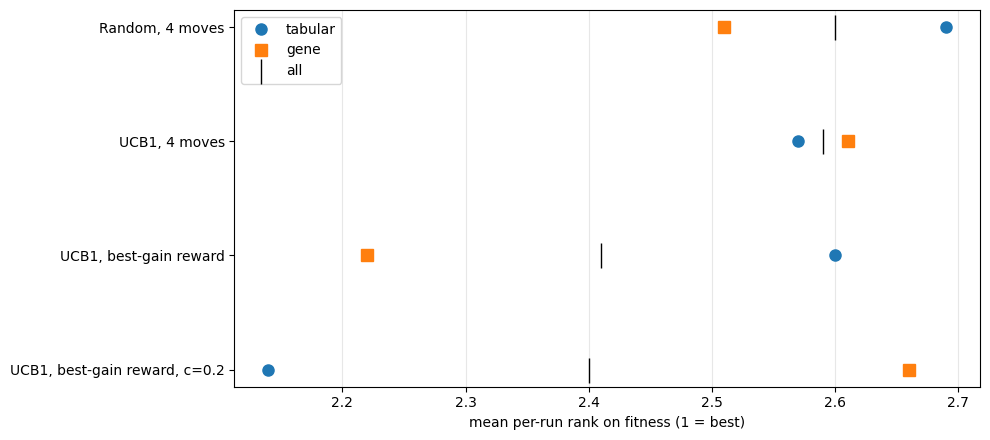

In [14]:
fig, ax = plt.subplots(figsize=(10, 4.5))
rk = mean_ranks(R, NAMES, "fit", False)
for grp, mk in (("tabular", "o"), ("gene", "s")):
    cols_g = [d for d in rk.columns if GROUP[d] == grp]
    if cols_g: ax.plot(rk[cols_g].mean(1).values, range(len(NAMES)), mk, label=grp, ms=8)
ax.plot(rk.mean(1).values, range(len(NAMES)), "k|", ms=18, label="all")
ax.set_yticks(range(len(NAMES))); ax.set_yticklabels(NAMES); ax.invert_yaxis()
ax.set_xlabel("mean per-run rank on fitness (1 = best)"); ax.legend(); ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v6_ranks.png", dpi=200); plt.show()

## 13. Download the results (everything except the caches and raw data)

In [15]:
zpath = f"{ROOT}/rl_doho_v6_reward_results.zip"
with zipfile.ZipFile(zpath, "w", zipfile.ZIP_DEFLATED) as z:
    for f in sorted(os.listdir(OUT_DIR)):
        if f.startswith("cache_") or f.endswith(".tmp") or os.path.isdir(f"{OUT_DIR}/{f}"): continue
        z.write(f"{OUT_DIR}/{f}", f"rl_doho_results_v6_reward/{f}")
print("Wrote", zpath, f"({os.path.getsize(zpath) / 1e6:.1f} MB)")
if IN_COLAB:
    from google.colab import files
    files.download(zpath)

Wrote /content/drive/MyDrive/rl_doho_v6_reward_results.zip (1.1 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. How to read the outcome
- **If H11a or H11b passes the success rule:** the controller matters once its reward targets the best subset. That variant becomes the recommended RL-DOHO configuration.
- **If neither passes, but the bandit now favours the high-improvement moves (positive Spearman in Section 10):** the bandit learns the right preference, but acting on it gains nothing over random choice within these budgets. That is the strongest form of the negative result.
- **If the bandit does not favour them:** the signal is too sparse, because most decisions improve nothing, for a bandit to learn from in about 100 decisions.

Report both H11 results in every case, as with H1–H10.